# Load packages

In [18]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, cohen_kappa_score, confusion_matrix, mean_squared_error, r2_score
import rioxarray as rio

# Load data

In [19]:
# Load plot locations

PLOT_COORDS_FPATH = 'data/SPL2018_EFI_ground_plots/SPL2018_EFI_ground_plots/PRF_SPL2018_EFI_plots_pts_wgs84.shp'

LABELS_FPATH = 'data/labels.csv'

ALS_METRICS_FPATH = r'data/als_metrics.tif'

plots_gdf = gpd.read_file(PLOT_COORDS_FPATH).rename(columns={"Plot": "plot_id"})

labels_df = pd.read_csv(LABELS_FPATH)

labels_df

,plot_id,dom_sp_type,perc_decid,total_agb_mg_ha,split
0,PRF013,conif,0.000000,42.263648,train
1,PRF090,mixed,52.285188,127.743892,train
2,PRF015,conif,5.186690,172.347008,train
3,PRF146,conif,3.228891,174.069178,train
4,PRF208R,conif,0.000000,13.298206,train
...,...,...,...,...,...
244,PRF212,conif,26.719682,141.950651,test
245,PRF049,mixed,66.054144,36.550006,test
246,PRF161,decid,98.688073,131.689708,test
247,PRF199,conif,5.880717,133.009047,test


# Extract ALS Metrics

In [20]:
als_metrics = rio.open_rasterio(ALS_METRICS_FPATH)
als_metrics

<xarray.DataArray (band: 67, y: 366, x: 746)> Size: 73MB
[18293412 values with dtype=float32]
Coordinates:
  * band         (band) int64 536B 1 2 3 4 5 6 7 8 9 ... 60 61 62 63 64 65 66 67
  * y            (y) float64 3kB 5.099e+06 5.099e+06 ... 5.09e+06 5.09e+06
  * x            (x) float64 6kB 2.974e+05 2.974e+05 ... 3.16e+05 3.16e+05
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    _FillValue:     -3.4028235e+38
    scale_factor:   1.0
    add_offset:     0.0
    long_name:      ('avg_95', 'avg', 'b10', 'b20', 'b30', 'b40', 'b50', 'b60...

Ensure that raster and plot coordinates are in the same CRS.

In [21]:
assert plots_gdf.crs == als_metrics.rio.crs, "CRS mismatch between plots and raster data."

Convert ALS metric names from a tuple to a list for later use.

In [22]:
als_metrics_nms = list(als_metrics.long_name)

In [23]:
plot_coords = [(geom.x, geom.y) for geom in plots_gdf.geometry]

for i, metric in enumerate(als_metrics_nms):

    print(f"Extracting metric: {metric}")

    metric_ras_i = als_metrics[i]
    plots_gdf[metric] = [float(metric_ras_i.sel(x=c[0], y=c[1], method="nearest").values) for c in plot_coords]

Extracting metric: avg_95
Extracting metric: avg
Extracting metric: b10
Extracting metric: b20
Extracting metric: b30
Extracting metric: b40
Extracting metric: b50
Extracting metric: b60
Extracting metric: b70
Extracting metric: b80
Extracting metric: b90
Extracting metric: dns_10m
Extracting metric: dns_12m
Extracting metric: dns_14m
Extracting metric: dns_15m
Extracting metric: dns_16m
Extracting metric: dns_18m
Extracting metric: dns_20m
Extracting metric: dns_25m
Extracting metric: dns_2m
Extracting metric: dns_4m
Extracting metric: dns_5m
Extracting metric: dns_6m
Extracting metric: dns_8m
Extracting metric: kur_95
Extracting metric: p01
Extracting metric: p05
Extracting metric: p10
Extracting metric: p20
Extracting metric: p30
Extracting metric: p40
Extracting metric: p50
Extracting metric: p60
Extracting metric: p70
Extracting metric: p80
Extracting metric: p90
Extracting metric: p95
Extracting metric: p99
Extracting metric: qav
Extracting metric: skew_95
Extracting metric: d0_2

Lets view the distribution of the 99th height percentile, it looks normal.

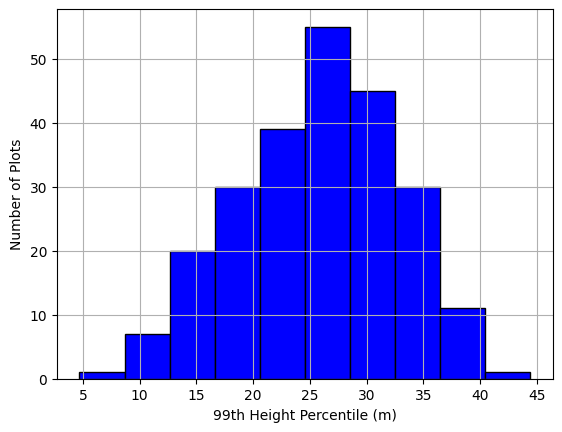

In [24]:
ax = plots_gdf['p99'].hist(edgecolor='black', color='blue')
ax.set_xlabel('99th Height Percentile (m)')
ax.set_ylabel('Number of Plots')
plt.show()

# Prepare data for RF Modelling

In [25]:
# Join metrics with labels
df = labels_df.merge(pd.DataFrame(plots_gdf), on='plot_id', how='left')

# Check which ALS metric cols have NAs
na_counts = df.isna().sum()

# Print all cols with NAs
for col, na_count in na_counts.items():
    if na_count > 0:
        print(f"{col}: {na_count} NAs")

# Drop rows with any NAs
df = df.dropna()
df

avg_95: 10 NAs
avg: 10 NAs
b10: 10 NAs
b20: 10 NAs
b30: 10 NAs
b40: 10 NAs
b50: 10 NAs
b60: 10 NAs
b70: 10 NAs
b80: 10 NAs
b90: 10 NAs
dns_10m: 10 NAs
dns_12m: 10 NAs
dns_14m: 10 NAs
dns_15m: 10 NAs
dns_16m: 10 NAs
dns_18m: 10 NAs
dns_20m: 10 NAs
dns_25m: 10 NAs
dns_2m: 10 NAs
dns_4m: 10 NAs
dns_5m: 10 NAs
dns_6m: 10 NAs
dns_8m: 10 NAs
kur_95: 10 NAs
p01: 10 NAs
p05: 10 NAs
p10: 10 NAs
p20: 10 NAs
p30: 10 NAs
p40: 10 NAs
p50: 10 NAs
p60: 10 NAs
p70: 10 NAs
p80: 10 NAs
p90: 10 NAs
p95: 10 NAs
p99: 10 NAs
qav: 10 NAs
skew_95: 10 NAs
d0_2: 10 NAs
d10_12: 10 NAs
d12_14: 10 NAs
d14_16: 10 NAs
d16_18: 10 NAs
d18_20: 10 NAs
d20_22: 10 NAs
d22_24: 10 NAs
d24_26: 10 NAs
d26_28: 10 NAs
d28_30: 10 NAs
d2_4: 10 NAs
d30_32: 10 NAs
d32_34: 10 NAs
d34_36: 10 NAs
d36_38: 10 NAs
d38_40: 10 NAs
d40_42: 10 NAs
d42_44: 10 NAs
d44_46: 10 NAs
d46_48: 10 NAs
d4_6: 10 NAs
d6_8: 10 NAs
d8_10: 10 NAs
std_95: 10 NAs
vci_1mbin: 10 NAs
vci_0.5bin: 10 NAs


,plot_id,dom_sp_type,perc_decid,total_agb_mg_ha,split,Date,Northing,Easting,Source,geometry,...,d40_42,d42_44,d44_46,d46_48,d4_6,d6_8,d8_10,std_95,vci_1mbin,vci_0.5bin
1,PRF090,mixed,52.285188,127.743892,train,October 24 2018,5093451.888,301051.062,Topcon HiperSR PPP,POINT Z (301050.862 5093452.903 0),...,0.0,0.0,0.0,0.0,1.4,4.2,7.3,6.69,0.84,0.84
2,PRF015,conif,5.186690,172.347008,train,October 3 2018,5095722.944,308784.843,Topcon Hiper V PPP,POINT Z (308784.644 5095723.959 0),...,0.0,0.0,0.0,0.0,2.8,6.0,8.5,8.08,0.91,0.91
4,PRF208R,conif,0.000000,13.298206,train,August 7 2018,5098426.096,312924.933,Topcon Hiper V PPP,POINT Z (312924.734 5098427.112 0),...,0.0,0.0,0.0,0.0,8.3,0.0,0.0,1.17,0.86,0.88
5,PRF324,conif,0.117878,102.643698,train,November 23 2018,5097473.520,313249.330,Topcon HiperSR PPP,POINT Z (313249.132 5097474.536 0),...,0.0,0.0,0.0,0.0,2.5,1.8,1.4,8.84,0.73,0.76
6,PRF211,conif,10.348340,90.645899,train,July 12 2018,5095450.682,308274.089,Topcon Hiper V PPP,POINT Z (308273.89 5095451.697 0),...,0.0,0.0,0.0,0.0,3.4,10.9,25.0,3.42,0.83,0.86
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
244,PRF212,conif,26.719682,141.950651,test,November 23 2018,5094601.988,300072.855,Topcon HiperSR PPP,POINT Z (300072.654 5094603.003 0),...,0.0,0.0,0.0,0.0,1.8,2.1,2.1,7.81,0.86,0.88
245,PRF049,mixed,66.054144,36.550006,test,November 23 2018,5092004.152,304173.914,Topcon Hiper V PPP,POINT Z (304173.714 5092005.167 0),...,0.0,0.0,0.0,0.0,2.9,1.0,2.2,3.26,0.56,0.64
246,PRF161,decid,98.688073,131.689708,test,August 13 2018,5095552.397,311148.042,Topcon Hiper V PPP,POINT Z (311147.843 5095553.412 0),...,0.0,0.0,0.0,0.0,0.4,0.9,0.7,4.88,0.77,0.81
247,PRF199,conif,5.880717,133.009047,test,October 9 2018,5096083.126,300478.721,Topcon Hiper V PPP,POINT Z (300478.52 5096084.141 0),...,0.0,0.0,0.0,0.0,1.6,2.2,2.2,9.71,0.72,0.73


In [26]:
# Assign nummieric IDs to each dominant species
df['dom_sp_type_id'] = df['dom_sp_type'].astype('category').cat.codes

# Create a dictionary mapping species names to their IDs
dom_sp_dict = (df[['dom_sp_type', 'dom_sp_type_id']]
               .drop_duplicates()
               .sort_values(by='dom_sp_type_id')
               .set_index('dom_sp_type_id', drop=True)
               .to_dict()['dom_sp_type'])

dom_sp_dict

{0: 'conif', 1: 'decid', 2: 'mixed'}

In [27]:
train_df = df[df['split'] == 'train'].reset_index(drop=True)
test_df = df[df['split'].isin(('val', 'test'))].reset_index(drop=True)

train_df.columns

Index(['plot_id', 'dom_sp_type', 'perc_decid', 'total_agb_mg_ha', 'split',
       'Date', 'Northing', 'Easting', 'Source', 'geometry', 'avg_95', 'avg',
       'b10', 'b20', 'b30', 'b40', 'b50', 'b60', 'b70', 'b80', 'b90',
       'dns_10m', 'dns_12m', 'dns_14m', 'dns_15m', 'dns_16m', 'dns_18m',
       'dns_20m', 'dns_25m', 'dns_2m', 'dns_4m', 'dns_5m', 'dns_6m', 'dns_8m',
       'kur_95', 'p01', 'p05', 'p10', 'p20', 'p30', 'p40', 'p50', 'p60', 'p70',
       'p80', 'p90', 'p95', 'p99', 'qav', 'skew_95', 'd0_2', 'd10_12',
       'd12_14', 'd14_16', 'd16_18', 'd18_20', 'd20_22', 'd22_24', 'd24_26',
       'd26_28', 'd28_30', 'd2_4', 'd30_32', 'd32_34', 'd34_36', 'd36_38',
       'd38_40', 'd40_42', 'd42_44', 'd44_46', 'd46_48', 'd4_6', 'd6_8',
       'd8_10', 'std_95', 'vci_1mbin', 'vci_0.5bin', 'dom_sp_type_id'],
      dtype='object')

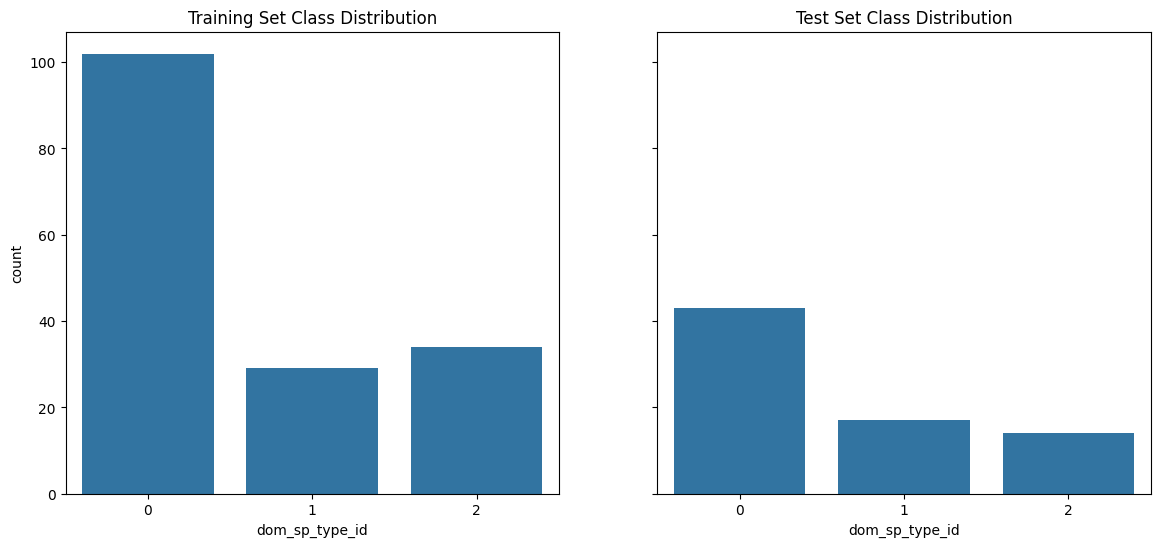

In [28]:
# Split data into train and test sets (combine val into test since not needed as seperate for RF)
train_df = df[df['split'] == 'train'].reset_index(drop=True)
test_df = df[df['split'].isin(('val', 'test'))].reset_index(drop=True)

# Create histograms showing each dataset class distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
sns.countplot(x='dom_sp_type_id', data=train_df, ax=axes[0])
axes[0].set_title('Training Set Class Distribution')
sns.countplot(x='dom_sp_type_id', data=test_df, ax=axes[1])
axes[1].set_title('Test Set Class Distribution')


plt.show()

# Train RF for Dominant Species Type Classification

In [29]:
def plot_feature_importance(rf, als_metrics_nms, title):
    importances = rf.feature_importances_
    importance_df = pd.DataFrame({'Metric': als_metrics_nms, 'importance': importances
                                    }).sort_values(by='importance', ascending=False)
    plt.figure(figsize=(10, 6))
    sns.barplot(x='importance', y='Metric', hue='importance', data=importance_df, palette='viridis')
    plt.title(title)
    plt.yticks(fontsize=5)
    plt.xlabel('Importance Score')
    plt.show()

Overall Accuracy: 0.76
Kappa: 0.56
Class 0 (conif): Accuracy = 0.88
Class 1 (decid): Accuracy = 0.82
Class 2 (mixed): Accuracy = 0.29


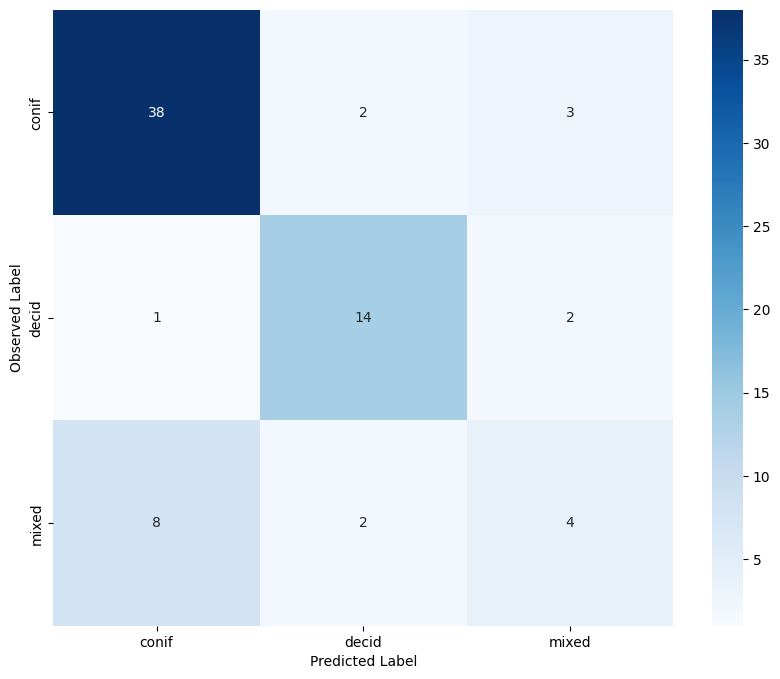

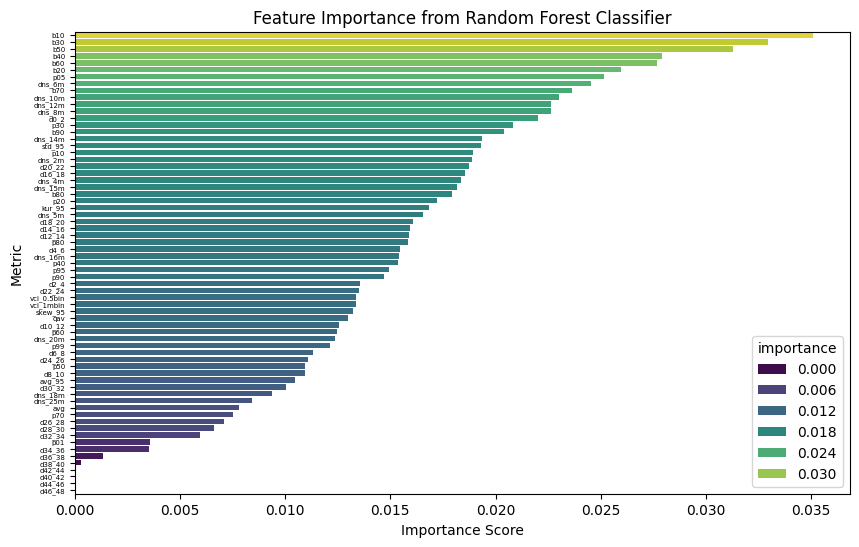

In [32]:
rf = RandomForestClassifier(n_estimators=100, random_state=25)

rf.fit(train_df[als_metrics_nms], train_df['dom_sp_type_id'])

# Apply the model to the test set
test_df['pred_dom_sp_group_id'] = rf.predict(test_df[als_metrics_nms])

# Calculate accuracy and kappa
accuracy = accuracy_score(test_df['dom_sp_type_id'], test_df['pred_dom_sp_group_id'])
kappa = cohen_kappa_score(test_df['dom_sp_type_id'], test_df['pred_dom_sp_group_id'])

print(f"Overall Accuracy: {accuracy:.2f}")
print(f"Kappa: {kappa:.2f}")

# Class specific accuracies
class_accuracies = {}
for class_id in test_df['dom_sp_type_id'].unique():
    class_mask = test_df['dom_sp_type_id'] == class_id
    class_accuracy = accuracy_score(test_df.loc[class_mask, 'dom_sp_type_id'],
                                    test_df.loc[class_mask, 'pred_dom_sp_group_id'])
    class_accuracies[class_id] = class_accuracy
    print(f"Class {class_id} ({dom_sp_dict[class_id]}): Accuracy = {class_accuracy:.2f}")


# Print confusion matrix
conf_matrix = confusion_matrix(test_df['dom_sp_type_id'], test_df['pred_dom_sp_group_id'])

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=dom_sp_dict.values(),
            yticklabels=dom_sp_dict.values())
plt.xlabel('Predicted Label')
plt.ylabel('Observed Label')

# View metric importance
plot_feature_importance(rf, als_metrics_nms, title='Feature Importance from Random Forest Classifier')



# Train RF for AGB estimation

R²: 0.58
RMSE: 43.78 mg/ha
Bias: -7.45 mg/ha


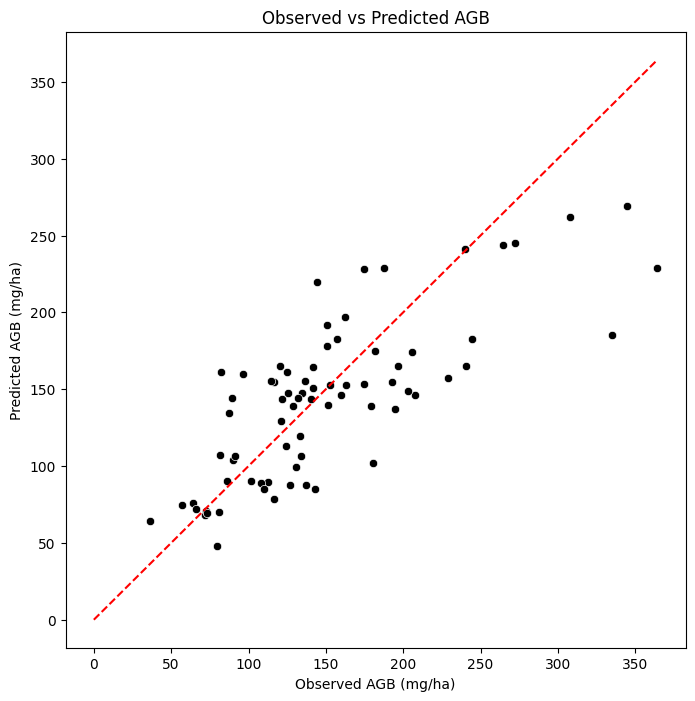

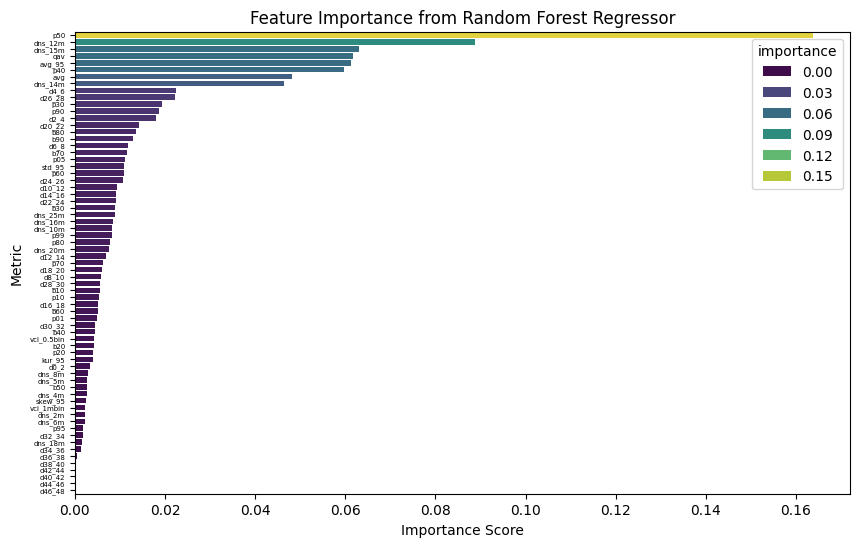

In [31]:
rf = RandomForestRegressor(n_estimators=100, random_state=25)

rf.fit(train_df[als_metrics_nms], train_df['total_agb_mg_ha'])

test_df['pred_agb'] = rf.predict(test_df[als_metrics_nms])

# Calculate regression metrics
r2 = r2_score(test_df['total_agb_mg_ha'], test_df['pred_agb'])
mse = mean_squared_error(test_df['total_agb_mg_ha'], test_df['pred_agb'])
rmse = np.sqrt(mse)
bias = np.mean(test_df['pred_agb'] - test_df['total_agb_mg_ha'])

print(f"R²: {r2:.2f}")
print(f"RMSE: {rmse:.2f} mg/ha")
print(f"Bias: {bias:.2f} mg/ha")

# Plot observed vs predicted AGB
plt.figure(figsize=(8, 8))
sns.scatterplot(x='total_agb_mg_ha', y='pred_agb', data=test_df, color='black')
plt.plot([0, test_df['total_agb_mg_ha'].max()], [0, test_df['total_agb_mg_ha'].max()], color='red', linestyle='--')
plt.xlabel('Observed AGB (mg/ha)')
plt.ylabel('Predicted AGB (mg/ha)')
plt.title('Observed vs Predicted AGB')
plt.show()

plot_feature_importance(rf, als_metrics_nms, title='Feature Importance from Random Forest Regressor')